# Task 2. Классификация изображений SVHN с MLP на NumPy

Задача: взять данные изображений для классификации, реализовать слои `FullyConnectedLayer -> ReluLayer -> FullyConnectedLayer`, использовать `CrossEntropyLoss` и L2-регуляризацию, подобрать learning rate на validation, оценить качество на test, анализировать train/val loss и проверять градиенты разностной оценкой.

Дополнительно реализованы `BatchNormLayer`, `Momentum`, `RMSProp` и `Adam`.

In [1]:
import os
import urllib.request
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import scipy.io

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path("task_2") if Path("task_2").exists() else Path(".")
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_LIMIT = 20000
VAL_SIZE = 5000
TEST_LIMIT = 5000

IMAGE_SIZE = 32
CHANNELS = 3
INPUT_SIZE = IMAGE_SIZE * IMAGE_SIZE * CHANNELS
NUM_CLASSES = 10


## Загрузка и подготовка SVHN

Используется официальный формат `train_32x32.mat` / `test_32x32.mat` с сайта Stanford. В SVHN метка цифры `0` хранится как `10`, поэтому ниже она заменяется на `0`.

In [2]:
def download_svhn(data_dir):
    base_url = "http://ufldl.stanford.edu/housenumbers"
    file_names = ["train_32x32.mat", "test_32x32.mat"]
    for file_name in file_names:
        file_path = data_dir / file_name
        if not file_path.exists():
            print(f"Скачивание {file_name}...")
            urllib.request.urlretrieve(f"{base_url}/{file_name}", file_path)
    return data_dir / file_names[0], data_dir / file_names[1]

def prepare_svhn_matrix(mat):
    X = mat["X"]
    y = mat["y"].flatten().astype(np.int64)
    y[y == 10] = 0
    X = X.transpose((3, 0, 1, 2))
    X = X.reshape(X.shape[0], -1)
    X = X.astype(np.float32) / 255.0
    return X, y

train_path, test_path = download_svhn(DATA_DIR)
train_mat = scipy.io.loadmat(train_path)
test_mat = scipy.io.loadmat(test_path)

X_train_full, y_train_full = prepare_svhn_matrix(train_mat)
X_test_full, y_test_full = prepare_svhn_matrix(test_mat)

X_val = X_train_full[:VAL_SIZE]
y_val = y_train_full[:VAL_SIZE]
X_train = X_train_full[VAL_SIZE : VAL_SIZE + TRAIN_LIMIT]
y_train = y_train_full[VAL_SIZE : VAL_SIZE + TRAIN_LIMIT]
X_test = X_test_full[:TEST_LIMIT]
y_test = y_test_full[:TEST_LIMIT]

print("train:", X_train.shape, y_train.shape)
print("val:", X_val.shape, y_val.shape)
print("test:", X_test.shape, y_test.shape)


train: (20000, 3072) (20000,)
val: (5000, 3072) (5000,)
test: (5000, 3072) (5000,)


In [3]:
class FullyConnectedLayer:
    def __init__(self, in_features, out_features):
        scale = np.sqrt(2.0 / in_features)
        self.W = np.random.randn(in_features, out_features).astype(np.float32) * scale
        self.b = np.zeros(out_features, dtype=np.float32)
        self.X = None
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, X, training=True):
        self.X = X
        return X @ self.W + self.b

    def backward(self, dY):
        self.dW = self.X.T @ dY
        self.db = np.sum(dY, axis=0)
        return dY @ self.W.T

    def params_and_grads(self):
        return [(self.W, self.dW), (self.b, self.db)]

class ReluLayer:
    def __init__(self):
        self.mask = None

    def forward(self, X, training=True):
        self.mask = X > 0
        return X * self.mask

    def backward(self, dY):
        return dY * self.mask

    def params_and_grads(self):
        return []

class BatchNormLayer:
    def __init__(self, features, momentum=0.9, eps=1e-5):
        self.gamma = np.ones(features, dtype=np.float32)
        self.beta = np.zeros(features, dtype=np.float32)
        self.running_mean = np.zeros(features, dtype=np.float32)
        self.running_var = np.ones(features, dtype=np.float32)
        self.momentum = momentum
        self.eps = eps
        self.cache = None
        self.dgamma = np.zeros_like(self.gamma)
        self.dbeta = np.zeros_like(self.beta)

    def forward(self, X, training=True):
        if training:
            batch_mean = np.mean(X, axis=0)
            batch_var = np.var(X, axis=0)
            X_centered = X - batch_mean
            inv_std = 1.0 / np.sqrt(batch_var + self.eps)
            X_norm = X_centered * inv_std
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * batch_mean
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * batch_var
            self.cache = (X_norm, X_centered, inv_std, batch_var)
        else:
            X_norm = (X - self.running_mean) / np.sqrt(self.running_var + self.eps)
        return self.gamma * X_norm + self.beta

    def backward(self, dY):
        X_norm, X_centered, inv_std, batch_var = self.cache
        n = dY.shape[0]
        self.dgamma = np.sum(dY * X_norm, axis=0)
        self.dbeta = np.sum(dY, axis=0)
        dX_norm = dY * self.gamma
        dvar = np.sum(dX_norm * X_centered * -0.5 * inv_std**3, axis=0)
        dmean = np.sum(-dX_norm * inv_std, axis=0) + dvar * np.mean(-2.0 * X_centered, axis=0)
        dX = dX_norm * inv_std + dvar * 2.0 * X_centered / n + dmean / n
        return dX

    def params_and_grads(self):
        return [(self.gamma, self.dgamma), (self.beta, self.dbeta)]


In [4]:
class CrossEntropyLoss:
    def forward(self, logits, y):
        n = logits.shape[0]
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp_logits = np.exp(shifted)
        probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        loss = -np.mean(np.log(probs[np.arange(n), y] + 1e-9))
        d_logits = probs.copy()
        d_logits[np.arange(n), y] -= 1.0
        d_logits /= n
        return loss, d_logits

def l2_regularization(model, l2_reg):
    total = 0.0
    for layer in model.layers:
        if isinstance(layer, FullyConnectedLayer):
            total += 0.5 * l2_reg * np.sum(layer.W * layer.W)
    return total

class MLPClassifier:
    def __init__(self, in_features, hidden_size, num_classes, use_batchnorm=False):
        self.layers = []
        self.layers.append(FullyConnectedLayer(in_features, hidden_size))
        if use_batchnorm:
            self.layers.append(BatchNormLayer(hidden_size))
        self.layers.append(ReluLayer())
        self.layers.append(FullyConnectedLayer(hidden_size, num_classes))

    def forward(self, X, training=True):
        out = X
        for layer in self.layers:
            out = layer.forward(out, training=training)
        return out

    def backward(self, d_logits, l2_reg):
        d_out = d_logits
        for layer in reversed(self.layers):
            d_out = layer.backward(d_out)
        for layer in self.layers:
            if isinstance(layer, FullyConnectedLayer):
                layer.dW += l2_reg * layer.W

    def params_and_grads(self):
        pairs = []
        for layer in self.layers:
            pairs.extend(layer.params_and_grads())
        return pairs


In [5]:
class SGD:
    def __init__(self, lr):
        self.lr = lr

    def step(self, pairs):
        for param, grad in pairs:
            param -= self.lr * grad

class Momentum:
    def __init__(self, lr, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.velocities = {}

    def step(self, pairs):
        for param, grad in pairs:
            key = id(param)
            if key not in self.velocities:
                self.velocities[key] = np.zeros_like(param)
            self.velocities[key] = self.momentum * self.velocities[key] - self.lr * grad
            param += self.velocities[key]

class RMSProp:
    def __init__(self, lr, decay=0.99, eps=1e-8):
        self.lr = lr
        self.decay = decay
        self.eps = eps
        self.cache = {}

    def step(self, pairs):
        for param, grad in pairs:
            key = id(param)
            if key not in self.cache:
                self.cache[key] = np.zeros_like(param)
            self.cache[key] = self.decay * self.cache[key] + (1 - self.decay) * grad * grad
            param -= self.lr * grad / (np.sqrt(self.cache[key]) + self.eps)

class Adam:
    def __init__(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}
        self.v = {}
        self.t = 0

    def step(self, pairs):
        self.t += 1
        for param, grad in pairs:
            key = id(param)
            if key not in self.m:
                self.m[key] = np.zeros_like(param)
                self.v[key] = np.zeros_like(param)
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grad
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * grad * grad
            m_hat = self.m[key] / (1 - self.beta1**self.t)
            v_hat = self.v[key] / (1 - self.beta2**self.t)
            param -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


In [6]:
criterion = CrossEntropyLoss()

def batch_loss_and_grad(model, X_batch, y_batch, l2_reg):
    logits = model.forward(X_batch, training=True)
    ce_loss, d_logits = criterion.forward(logits, y_batch)
    total_loss = ce_loss + l2_regularization(model, l2_reg)
    model.backward(d_logits, l2_reg)
    return float(total_loss)

def predict(model, X, batch_size=2048):
    predictions = []
    for start in range(0, X.shape[0], batch_size):
        X_batch = X[start : start + batch_size]
        logits = model.forward(X_batch, training=False)
        predictions.append(np.argmax(logits, axis=1))
    return np.concatenate(predictions)

def accuracy(model, X, y):
    y_pred = predict(model, X)
    return float(np.mean(y_pred == y))

def mean_loss(model, X, y, l2_reg, batch_size=2048):
    total_ce = 0.0
    total_count = 0
    for start in range(0, X.shape[0], batch_size):
        X_batch = X[start : start + batch_size]
        y_batch = y[start : start + batch_size]
        logits = model.forward(X_batch, training=False)
        ce_loss, _ = criterion.forward(logits, y_batch)
        total_ce += float(ce_loss) * X_batch.shape[0]
        total_count += X_batch.shape[0]
    return total_ce / total_count + l2_regularization(model, l2_reg)

def gradient_check(model, X_small, y_small, l2_reg, epsilon=1e-5, checks=10):
    batch_loss_and_grad(model, X_small, y_small, l2_reg)
    pairs = model.params_and_grads()
    errors = []
    for _ in range(checks):
        param, grad = pairs[np.random.randint(len(pairs))]
        index = tuple(np.random.randint(size) for size in param.shape)
        old_value = param[index]
        param[index] = old_value + epsilon
        plus = mean_loss(model, X_small, y_small, l2_reg, batch_size=X_small.shape[0])
        param[index] = old_value - epsilon
        minus = mean_loss(model, X_small, y_small, l2_reg, batch_size=X_small.shape[0])
        param[index] = old_value
        numeric_grad = (plus - minus) / (2 * epsilon)
        analytic_grad = grad[index]
        rel_error = abs(numeric_grad - analytic_grad) / (abs(numeric_grad) + abs(analytic_grad) + 1e-8)
        errors.append(float(rel_error))
    return max(errors), float(np.mean(errors))

def make_optimizer(name, lr):
    if name == "sgd":
        return SGD(lr)
    if name == "momentum":
        return Momentum(lr)
    if name == "rmsprop":
        return RMSProp(lr)
    if name == "adam":
        return Adam(lr)
    raise ValueError(f"Unknown optimizer: {name}")


In [7]:
def train_model(
    lr,
    optimizer_name="adam",
    hidden_size=128,
    use_batchnorm=True,
    epochs=5,
    batch_size=256,
    l2_reg=1e-4,
):
    np.random.seed(RANDOM_STATE)
    model = MLPClassifier(INPUT_SIZE, hidden_size, NUM_CLASSES, use_batchnorm=use_batchnorm)
    optimizer = make_optimizer(optimizer_name, lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start_time = perf_counter()
    for epoch in range(epochs):
        permutation = np.random.permutation(X_train.shape[0])
        batch_losses = []
        for start in range(0, X_train.shape[0], batch_size):
            batch_indices = permutation[start : start + batch_size]
            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]
            loss = batch_loss_and_grad(model, X_batch, y_batch, l2_reg)
            optimizer.step(model.params_and_grads())
            batch_losses.append(loss)
        history["train_loss"].append(float(np.mean(batch_losses)))
        history["val_loss"].append(mean_loss(model, X_val, y_val, l2_reg))
        history["train_acc"].append(accuracy(model, X_train[:5000], y_train[:5000]))
        history["val_acc"].append(accuracy(model, X_val, y_val))
        print(f"epoch {epoch + 1:02d}: train loss={history['train_loss'][-1]:.4f}, val loss={history['val_loss'][-1]:.4f}, val acc={history['val_acc'][-1]:.3f}")
    elapsed = perf_counter() - start_time
    return model, history, elapsed

X_check = X_train[:8]
y_check = y_train[:8]
check_model = MLPClassifier(INPUT_SIZE, hidden_size=16, num_classes=NUM_CLASSES, use_batchnorm=False)
max_error, mean_error = gradient_check(check_model, X_check, y_check, l2_reg=1e-4, checks=10)
print(f"gradient check: max relative error={max_error:.3e}, mean relative error={mean_error:.3e}")


gradient check: max relative error=3.040e-06, mean relative error=4.539e-07


In [8]:
learning_rates = [0.1, 0.05, 0.01, 0.005, 0.003, 0.001, 0.0007, 0.0005, 0.0003, 0.0001]
optimizer_name = "adam"
search_results = []
histories = {}
models = {}

for lr in learning_rates:
    print()
    print(f"Обучение модели с lr={lr}")
    model, history, elapsed = train_model(lr=lr, optimizer_name=optimizer_name)
    best_val_loss = min(history["val_loss"])
    best_val_acc = max(history["val_acc"])
    search_results.append({"lr": lr, "best_val_loss": best_val_loss, "best_val_acc": best_val_acc, "time_sec": elapsed})
    histories[lr] = history
    models[lr] = model

search_results = sorted(search_results, key=lambda row: row["best_val_loss"])
best_lr = search_results[0]["lr"]
best_model = models[best_lr]
print()
print("Результаты подбора lr:")
for row in search_results:
    print(row)
print()
print(f"Лучший learning rate: {best_lr}")



Обучение модели с lr=0.1


epoch 01: train loss=4.4198, val loss=3.3709, val acc=0.212


epoch 02: train loss=2.2560, val loss=4.5334, val acc=0.105


epoch 03: train loss=1.9642, val loss=2.5146, val acc=0.243


epoch 04: train loss=1.8677, val loss=2.8909, val acc=0.255


...

epoch 01: train loss=2.1857, val loss=2.0283, val acc=0.298


epoch 02: train loss=1.7610, val loss=1.7944, val acc=0.417


epoch 03: train loss=1.5344, val loss=1.6244, val acc=0.468


epoch 04: train loss=1.3997, val loss=1.5140, val acc=0.531


epoch 05: train loss=1.3088, val loss=1.5018, val acc=0.544

Результаты подбора lr:
{'lr': 0.0003, 'best_val_loss': np.float64(1.3954843451645336), 'best_val_acc': 0.5752, 'time_sec': 10.673516937000386}
{'lr': 0.001, 'best_val_loss': np.float64(1.4596642229525645), 'best_val_acc': 0.5522, 'time_sec': 7.18072637700061}
{'lr': 0.0005, 'best_val_loss': np.float64(1.4813674716067413), 'best_val_acc': 0.5228, 'time_sec': 7.837315221000608}
{'lr': 0.0001, 'best_val_loss': np.float64(1.501814874335202), 'best_val_acc': 0.5442, 'time_sec': 5.62699473199973}
{'lr': 0.0007, 'best_val_loss': np.float64(1.5471436274480057), 'best_val_acc': 0.529, 'time_sec': 8.07363086999976}
{'lr': 0.003, 'best_val_loss': np.float64(1.6115832607086167), 'best_val_acc': 0.5252, 'time_sec': 8.29184555000029}
{'lr': 0.005, 'best_val_loss': np.float64(1.7630685598967608), 'best_val_acc': 0.4996, 'time_sec': 8.070457022000483}
{'lr': 0.01, 'best_val_loss': np.float64(1.9956666579966522), 'best_val_acc': 0.4866, 'time

test loss: 1.8320
test accuracy: 42.96%


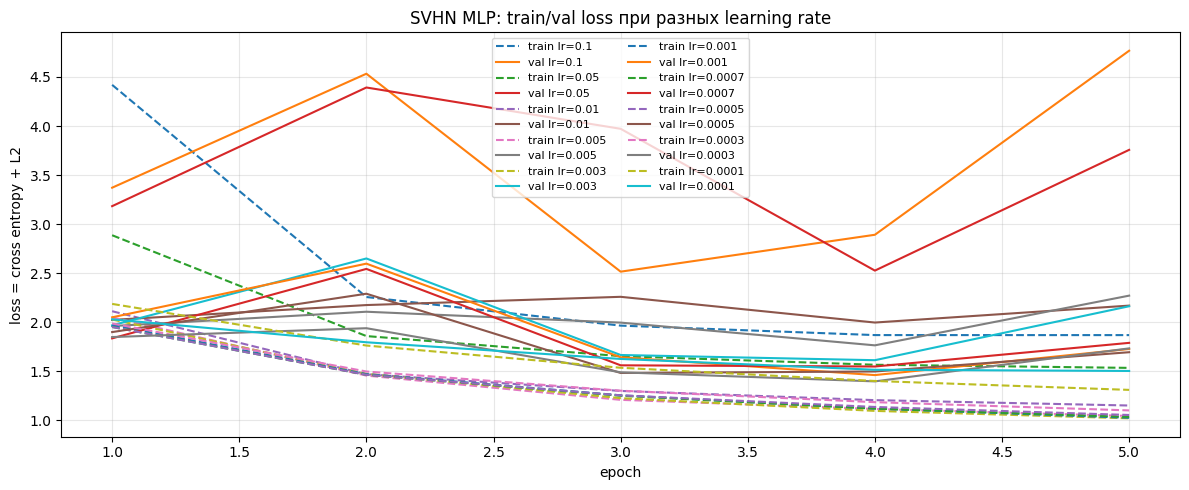

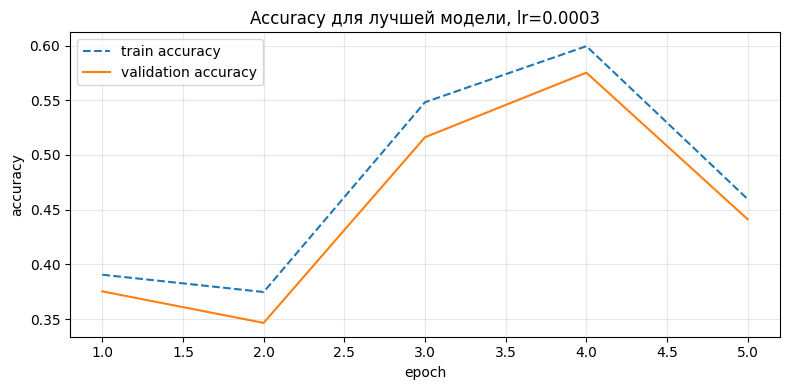

In [9]:
test_loss = mean_loss(best_model, X_test, y_test, l2_reg=1e-4)
test_acc = accuracy(best_model, X_test, y_test)
print(f"test loss: {test_loss:.4f}")
print(f"test accuracy: {100 * test_acc:.2f}%")

plt.figure(figsize=(12, 5))
for lr, history in histories.items():
    epochs_axis = np.arange(1, len(history["train_loss"]) + 1)
    plt.plot(epochs_axis, history["train_loss"], "--", label=f"train lr={lr}")
    plt.plot(epochs_axis, history["val_loss"], label=f"val lr={lr}")
plt.xlabel("epoch")
plt.ylabel("loss = cross entropy + L2")
plt.title("SVHN MLP: train/val loss при разных learning rate")
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
best_history = histories[best_lr]
epochs_axis = np.arange(1, len(best_history["val_acc"]) + 1)
plt.plot(epochs_axis, best_history["train_acc"], "--", label="train accuracy")
plt.plot(epochs_axis, best_history["val_acc"], label="validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title(f"Accuracy для лучшей модели, lr={best_lr}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
